## Imports and definitions


### Imports

In [114]:
import os
import re
import sys
import glob
import csv
import shutil
from datetime import datetime
from collections import defaultdict

import numpy as np
import numpy.ma as ma
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

from astropy.io import fits
from astropy.io.fits import getdata
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord

from scipy.ndimage import rotate, gaussian_filter1d, maximum_filter1d
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import medfilt, find_peaks, detrend
from scipy.special import wofz
from scipy import stats
from scipy.interpolate import CubicSpline

from lmfit.models import VoigtModel, ExponentialModel, SplineModel, LinearModel, GaussianModel, PolynomialModel, ConstantModel
from lmfit import report_fit

import pickle

### Grism Utils v2

In [115]:
import importlib
import grism_utils_v2
importlib.reload(grism_utils_v2)
from grism_utils_v2 import spectrum

### Functions

In [116]:
def _basename(path):
    return os.path.basename(str(path))

def get_obs_time(img_file):
    """
    Return astropy Time object for a FITS file.
    """
    with fits.open(img_file) as hdul:
        hdr = hdul[1].header  # you already use extension 1
        date_obs = hdr.get("DATE-OBS")

        if date_obs is None:
            raise ValueError(f"No DATE-OBS in {img_file}")

    return Time(date_obs, format='isot', scale='utc')

def _spec_file_key(S):
    """Key used to match a restored calibration object to a calibration image file."""
    if hasattr(S, "grism_image") and S.grism_image is not None:
        return _basename(S.grism_image)
    return None

def _build_spec_lookup(calib_spectra):
    """
    Build lookup: basename(grism_image) -> spectrum object
    """
    lookup = {}
    for S in calib_spectra:
        key = _spec_file_key(S)
        if key is not None:
            lookup[key] = S
    return lookup


def _save_calib_list_pickle(objects, filename, skip_flagged=False):
    """
    Save only selected attributes from a list of class objects.

    Parameters
    ----------
    objects : list
        List of class instances.
    filename : str
        Output pickle filename.
    include_attrs : list of str or None
        Attributes to save. If None, uses a compact calibration-focused default.
    skip_flagged : bool
        If True, skip objects with flagged=True.
    """

    include_attrs = [
        "object_name",
        "obs_date",
        "filter",
        "camera",
        "grism_image",
        "flagged",
        "hdr",
        "imsize_x",
        "imsize_y",
        "airmass",
        "exp_time",
        "moonangle",
        "moonphase",
        "trace_model",
        "telluric_pixel",
        "wavelength_range",
        "wavelength_correction",
        "wave_calib",
        "wave_r2",
        "wave_centroids",
        "pix_centroids",
        "wave_grid",
        "gain_smooth",
        "mean_fwhm",
        "median_fwhm",
        "std_fwhm"
    ]

    payload = []

    for obj in objects:
        if skip_flagged and getattr(obj, "flagged", False):
            continue

        row = {}

        for attr in include_attrs:
            val = getattr(obj, attr, None)

            try:
                # ensure it is pickleable
                pickle.dumps(val, protocol=pickle.HIGHEST_PROTOCOL)
                row[attr] = val
            except Exception:
                row[attr] = repr(val)

        payload.append(row)

    with open(filename, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved {len(payload)} objects to {filename}")

def restore_spectrum_objects_from_pickle(pkl_file, spectrum_class):
    """
    Restore lightweight spectrum-like objects from a pickle file
    containing a list of dictionaries.

    Parameters
    ----------
    pkl_file : str
        Path to pickle file.
    spectrum_class : class
        Your spectrum class from grism_utils_v2.py

    Returns
    -------
    objects : list
        List of restored spectrum_class instances.
    """
    with open(pkl_file, "rb") as f:
        data = pickle.load(f)

    objects = []

    for row in data:
        obj = spectrum_class.__new__(spectrum_class)  # bypass __init__

        for key, val in row.items():
            setattr(obj, key, val)

        # # Rebuild recessary attributes
        # # Assumes you saved wave_grid and either gain_smooth or gain
        # if hasattr(obj, "wave_grid"):
        #     if hasattr(obj, "gain_smooth"):
        #         obj.gain_spline = interp1d(
        #             obj.wave_grid,
        #             obj.gain_smooth,
        #             bounds_error=False,
        #             fill_value="extrapolate"
        #         )
        #     elif hasattr(obj, "gain"):
        #         obj.gain_spline = interp1d(
        #             obj.wave_grid,
        #             obj.gain,
        #             bounds_error=False,
        #             fill_value="extrapolate"
        #         )

        objects.append(obj)

    return objects

In [117]:
# ------------------------------------------------------------
# Helper functions for building averaged calibration objects
# ------------------------------------------------------------

def match_science_to_calib(img_files, calib_img_files, tbin=1800, verbose=True):
    """
    Build non-overlapping calibration bins in time, assign each science image
    to the bin containing its nearest calibration image, and keep only bins
    relevant to at least one science image.

    Parameters
    ----------
    img_files : list of str
        Science image filenames.
    calib_img_files : list of str
        Calibration image filenames.
    tbin : float
        Maximum bin width in seconds, measured relative to the first calibration
        image in each bin. Default = 1800 s.
    verbose : bool
        If True, print summary.

    Returns
    -------
    result : dict
        {
            "science_matches": list of dict,
            "calib_bins": list of dict,
            "calib_times": astropy Time array,
            "sorted_calib_files": list of str
        }
    """

    if len(img_files) == 0:
        raise ValueError("img_files is empty.")
    if len(calib_img_files) == 0:
        raise ValueError("calib_img_files is empty.")

    # ----------------------------------------------------------
    # Sort calibration images by time
    # ----------------------------------------------------------
    calib_times = Time([get_obs_time(f).isot for f in calib_img_files], scale="utc")
    calib_pairs = sorted(zip(calib_img_files, calib_times), key=lambda x: x[1].unix)

    sorted_calib_files = [f for f, t in calib_pairs]
    sorted_calib_times = Time([t for f, t in calib_pairs])

    # ----------------------------------------------------------
    # Build non-overlapping bins from calibration images
    # ----------------------------------------------------------
    raw_bins = []
    i = 0
    while i < len(sorted_calib_files):
        ref_file = sorted_calib_files[i]
        ref_time = sorted_calib_times[i]

        bin_files = [ref_file]
        bin_times = [ref_time]
        bin_indices = [i]

        i += 1
        while i < len(sorted_calib_files):
            dt_sec = sorted_calib_times[i].unix - ref_time.unix
            if dt_sec <= tbin:
                bin_files.append(sorted_calib_files[i])
                bin_times.append(sorted_calib_times[i])
                bin_indices.append(i)
                i += 1
            else:
                break

        bin_unix = np.array([t.unix for t in bin_times])
        mid_unix = np.median(bin_unix)
        rep_local_idx = int(np.argmin(np.abs(bin_unix - mid_unix)))

        raw_bins.append({
            "bin_id": len(raw_bins),
            "files": bin_files,
            "times": bin_times,
            "indices": bin_indices,
            "representative_file": bin_files[rep_local_idx],
            "representative_time": bin_times[rep_local_idx],
            "start_time": bin_times[0],
            "end_time": bin_times[-1],
            "n_files": len(bin_files),
        })

    # ----------------------------------------------------------
    # Assign science images to nearest calibration image / bin
    # ----------------------------------------------------------
    science_times = Time([get_obs_time(f).isot for f in img_files], scale="utc")
    science_matches = []

    for sci_file, sci_time in zip(img_files, science_times):
        dt = np.abs((sorted_calib_times - sci_time).to("s").value)
        nearest_idx = int(np.argmin(dt))

        nearest_calib_file = sorted_calib_files[nearest_idx]
        nearest_calib_time = sorted_calib_times[nearest_idx]
        nearest_dt_sec = float(dt[nearest_idx])

        matched_bin = None
        for b in raw_bins:
            if nearest_idx in b["indices"]:
                matched_bin = b
                break

        science_matches.append({
            "science_file": sci_file,
            "science_time": sci_time,
            "nearest_calib_file": nearest_calib_file,
            "nearest_calib_time": nearest_calib_time,
            "nearest_dt_sec": nearest_dt_sec,
            "bin_id": matched_bin["bin_id"],
            "calib_group_files": matched_bin["files"],
            "calib_group_times": matched_bin["times"],
            "representative_file": matched_bin["representative_file"],
            "representative_time": matched_bin["representative_time"],
        })

    # ----------------------------------------------------------
    # Keep only bins actually used by at least one science image
    # ----------------------------------------------------------
    used_bin_ids = sorted(set(row["bin_id"] for row in science_matches))
    used_bins = [raw_bins[bid] for bid in used_bin_ids]

    # remap to consecutive bin ids
    old_to_new = {old: new for new, old in enumerate(used_bin_ids)}

    calib_bins = []
    for b in used_bins:
        b_new = dict(b)
        b_new["bin_id"] = old_to_new[b["bin_id"]]
        calib_bins.append(b_new)

    for row in science_matches:
        old_bin = row["bin_id"]
        row["bin_id"] = old_to_new[old_bin]

    # refresh bin-linked fields in science_matches
    bin_lookup = {b["bin_id"]: b for b in calib_bins}
    for row in science_matches:
        b = bin_lookup[row["bin_id"]]
        row["calib_group_files"] = b["files"]
        row["calib_group_times"] = b["times"]
        row["representative_file"] = b["representative_file"]
        row["representative_time"] = b["representative_time"]

    # ----------------------------------------------------------
    # Verbose summary
    # ----------------------------------------------------------
    if verbose:
        date_start = sorted_calib_times[0].isot if len(sorted_calib_times) > 0 else "N/A"
        date_end = sorted_calib_times[-1].isot if len(sorted_calib_times) > 0 else "N/A"

        print("")
        print("Calibration bin summary")
        print("-----------------------")
        print(f"Found {len(calib_bins)} calibration bins")
        print(f"Calibration date range available: {date_start}  →  {date_end}")
        print(f"Total calibration images available: {len(sorted_calib_files)}")
        print(f"Science images: {len(img_files)}")
        print(f"Bin width criterion: {tbin:.0f} s ({tbin/60:.1f} min)")
        print("")

        # science grouped by bin
        sci_by_bin = {b['bin_id']: [] for b in calib_bins}
        for row in science_matches:
            sci_by_bin[row["bin_id"]].append(os.path.basename(row["science_file"]))

        for b in calib_bins:
            print(
                f"Bin {b['bin_id']:02d}: "
                f"{b['n_files']} calibration file(s), "
                f"{b['start_time'].isot} → {b['end_time'].isot}, "
                f"rep = {os.path.basename(b['representative_file'])}"
            )
            print("  Calibration files:")
            for f, t in zip(b["files"], b["times"]):
                print(f"    - {os.path.basename(f)}  [{t.isot}]")

            print("  Science images:")
            for sci_name in sci_by_bin[b["bin_id"]]:
                print(f"    - {sci_name}")
            print("")

    return {
        "science_matches": science_matches,
        "calib_bins": calib_bins,
        "calib_times": sorted_calib_times,
        "sorted_calib_files": sorted_calib_files,
    }

def _fit_poly_to_curve(x, y, degree):
    """
    Fit polynomial coeffs in np.polyval order (high -> low).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < degree + 1:
        raise ValueError("Not enough valid points to fit polynomial.")
    return np.polyfit(x[good], y[good], degree)

def _average_wavelength_solution(calib_group, npix=None, degree=None):
    good = [
        S for S in calib_group
        if not getattr(S, "flagged", False)
        and hasattr(S, "wave_calib")
        and getattr(S, "wave_calib", None) is not None
    ]

    if len(good) == 0:
        raise ValueError("No non-flagged calibration objects in group have wave_calib.")

    if npix is None:
        if hasattr(good[0], "imsize_x") and good[0].imsize_x is not None:
            npix = int(good[0].imsize_x)
        else:
            npix = 4096

    if degree is None:
        degree = len(np.asarray(good[0].wave_calib)) - 1

    x_common = np.arange(npix, dtype=float)

    wave_curves = []
    for S in good:
        c = np.asarray(S.wave_calib, dtype=float)
        wave_curves.append(np.polyval(c, x_common))

    wave_curves = np.array(wave_curves)
    wave_med = np.nanmean(wave_curves, axis=0)

    coeff_med = _fit_poly_to_curve(x_common, wave_med, degree=degree)

    return x_common, wave_med, coeff_med

def _average_gain_solution(calib_group):
    good = [
        S for S in calib_group
        if not getattr(S, "flagged", False)
        and hasattr(S, "wave_grid")
        and hasattr(S, "gain_smooth")
        and getattr(S, "wave_grid", None) is not None
        and getattr(S, "gain_smooth", None) is not None
    ]

    if len(good) == 0:
        raise ValueError("No non-flagged calibration objects in group have wave_grid/gain_smooth.")

    wave_mins = []
    wave_maxs = []

    for S in good:
        wave_i = np.asarray(S.wave_grid, dtype=float)
        gain_i = np.asarray(S.gain_smooth, dtype=float)

        if len(wave_i) != len(gain_i):
            continue

        valid = np.isfinite(wave_i) & np.isfinite(gain_i)
        if np.sum(valid) < 2:
            continue

        wave_mins.append(np.nanmin(wave_i[valid]))
        wave_maxs.append(np.nanmax(wave_i[valid]))

    if len(wave_mins) == 0:
        raise ValueError("No usable non-flagged gain curves after validation.")

    wmin = max(wave_mins)
    wmax = min(wave_maxs)

    if wmin >= wmax:
        raise ValueError("No overlapping wave_grid range in non-flagged calibration group.")

    n_common = min(len(np.asarray(S.wave_grid)) for S in good)
    wave_common = np.linspace(wmin, wmax, n_common)

    gain_curves = []

    for S in good:
        wave_i = np.asarray(S.wave_grid, dtype=float)
        gain_i = np.asarray(S.gain_smooth, dtype=float)

        if len(wave_i) != len(gain_i):
            continue

        valid = np.isfinite(wave_i) & np.isfinite(gain_i)
        wave_i = wave_i[valid]
        gain_i = gain_i[valid]

        if len(wave_i) < 2:
            continue

        order = np.argsort(wave_i)
        wave_i = wave_i[order]
        gain_i = gain_i[order]

        gain_curves.append(np.interp(wave_common, wave_i, gain_i))

    if len(gain_curves) == 0:
        raise ValueError("Could not interpolate any non-flagged gain curves.")

    gain_curves = np.array(gain_curves)
    gain_med = np.nanmean(gain_curves, axis=0)

    gain_interp = interp1d(
        wave_common,
        gain_med,
        bounds_error=False,
        fill_value="extrapolate"
    )

    return wave_common, gain_med, gain_interp

def build_averaged_calib_object(calib_group, spectrum_class, bin_id=None, npix=None, wave_degree=None):
    """
    Build a lightweight spectrum-like calibration object from a calibration group.
    Compatible with downstream code expecting .wave_calib, .gain_spline, etc.
    """
    if len(calib_group) == 0:
        raise ValueError("calib_group is empty.")

    template = calib_group[0]

    x_common, wave_med, coeff_med = _average_wavelength_solution(
        calib_group,
        npix=npix,
        degree=wave_degree
    )

    wave_common, gain_med, gain_interp = _average_gain_solution(calib_group)

    avg = spectrum_class.__new__(spectrum_class)

    # copy a few metadata attrs from template if present
    for attr in ["filter", "camera", "hdr"]:
        if hasattr(template, attr):
            setattr(avg, attr, getattr(template, attr))

    avg.object_name = f"AVG_CALIB_BIN_{bin_id}" if bin_id is not None else "AVG_CALIB"
    avg.grism_image = None
    avg.obs_date = None
    avg.flagged = False

    # wavelength-calibration attrs
    avg.wave_calib = coeff_med
    avg.wave_r2 = None
    avg.imsize_x = len(x_common)
    avg.wave_curve_avg = wave_med

    # gain-calibration attrs
    avg.wave_grid = wave_common
    avg.gain_smooth = gain_med
    avg.gain = gain_med.copy()
    avg.gain_spline = gain_interp

    # bookkeeping
    avg.bin_id = bin_id
    avg.calib_group_members = [getattr(S, "grism_image", None) for S in calib_group]

    return avg

# ------------------------------------------------------------
# Missing-calibration derivation
# ------------------------------------------------------------

def derive_single_calib_spectrum(grism_image, spectrum_class, filter):
    """
    Derive one calibration spectrum object from a calibration image.
    If derivation fails, return the partially-created object with flagged=True.
    """
    S = spectrum_class(grism_image, calib_spectrum=None, filter=filter, calib_img=True)

    try:
        trace_center, cutouts, subim = S.fit_trace(plot=False, curved=True)

        spec = S.extract_spectrum(
            show_box=False,
            plot=False,
            curved_box=True,
        )

        telluric_pixel = S.fit_telluric(plot=False)

        # If fit_telluric failed internally, catch that here
        if not hasattr(S, "telluric_pixel"):
            raise AttributeError("telluric_pixel was not created.")

        wavelength_correction = S.derive_wavelength_correction()
        wave_calib = S.derive_wavelength_solution(show_points=False, plot=False)
        waves = S.wavelength_calibrate()
        ref_wave, ref_flux = S.load_stelib_spectrum("STELIB")
        wave_grid, flux_data_interp, flux_ref_interp = S.match_and_interpolate()
        gain_curve = S.derive_gain_calibration(plot=False)

        S.flagged = False

    except Exception as e:
        print(f"  Flagging failed calibration image: {grism_image}")
        print(f"  Reason: {e}")

        S.flagged = True
        S.failure_reason = str(e)

    return S

def ensure_required_calib_spectra(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class,
    filter,
    save_updated=True,
    zwo_pkl=None,
    qhy_pkl=None,
    verbose=True
):
    zwo_lookup = _build_spec_lookup(ZWO_calib_spectra)
    qhy_lookup = _build_spec_lookup(QHY_calib_spectra)

    needed_calib_files = sorted({
        _basename(f)
        for row in matches["science_matches"]
        for f in row["calib_group_files"]
    })

    needed_fullpaths = {}
    for row in matches["science_matches"]:
        for f in row["calib_group_files"]:
            needed_fullpaths[_basename(f)] = f

    new_zwo = []
    new_qhy = []
    new_flagged = []
    skipped_existing_flagged = []

    for key in needed_calib_files:

        # Already exists in ZWO list
        if key in zwo_lookup:
            if getattr(zwo_lookup[key], "flagged", False):
                skipped_existing_flagged.append(key)
            continue

        # Already exists in QHY list
        if key in qhy_lookup:
            if getattr(qhy_lookup[key], "flagged", False):
                skipped_existing_flagged.append(key)
            continue

        fullpath = needed_fullpaths[key]

        if verbose:
            print(f"Deriving missing calibration spectrum: {key}")

        S = derive_single_calib_spectrum(fullpath, spectrum_class, filter)

        cam = getattr(S, "camera", None)

        if cam == "ASI Camer":
            ZWO_calib_spectra.append(S)
            zwo_lookup[key] = S
            new_zwo.append(key)
        elif cam == "QHYCCD-Ca":
            QHY_calib_spectra.append(S)
            qhy_lookup[key] = S
            new_qhy.append(key)
        else:
            # fallback
            ZWO_calib_spectra.append(S)
            zwo_lookup[key] = S
            new_zwo.append(key)
            if verbose:
                print(f"  Warning: unknown camera '{cam}' for {key}; appended to ZWO list.")

        if getattr(S, "flagged", False):
            new_flagged.append(key)

    if save_updated:
        if zwo_pkl is None:
            zwo_pkl = f"Calib_Spectra_{filter}_ZWO.pkl"
        if qhy_pkl is None:
            qhy_pkl = f"Calib_Spectra_{filter}_QHY.pkl"

        _save_calib_list_pickle(ZWO_calib_spectra, zwo_pkl)
        _save_calib_list_pickle(QHY_calib_spectra, qhy_pkl)

        if verbose:
            print("")
            print(f"Saved updated ZWO calibration list -> {zwo_pkl}")
            print(f"Saved updated QHY calibration list -> {qhy_pkl}")

    return {
        "ZWO_calib_spectra": ZWO_calib_spectra,
        "QHY_calib_spectra": QHY_calib_spectra,
        "new_zwo_files": new_zwo,
        "new_qhy_files": new_qhy,
        "new_flagged_files": new_flagged,
        "skipped_existing_flagged": skipped_existing_flagged,
    }

# ------------------------------------------------------------
# Build averaged per-bin calibration objects
# ------------------------------------------------------------

def build_bin_averaged_calibrations(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class,
    derivation_summary=None,
    verbose=True
):
    zwo_lookup = _build_spec_lookup(ZWO_calib_spectra)
    qhy_lookup = _build_spec_lookup(QHY_calib_spectra)

    bin_avg_lookup = {}
    failed_bins = []
    skipped_flagged_count = 0
    used_calib_count = 0

    for bin_info in matches["calib_bins"]:
        bin_id = bin_info["bin_id"]
        group_files = bin_info["files"]

        calib_group = []

        for f in group_files:
            key = _basename(f)

            if key in zwo_lookup:
                S = zwo_lookup[key]
            elif key in qhy_lookup:
                S = qhy_lookup[key]
            else:
                continue

            if getattr(S, "flagged", False):
                skipped_flagged_count += 1
                continue

            calib_group.append(S)

        used_calib_count += len(calib_group)

        if len(calib_group) == 0:
            failed_bins.append(bin_id)
            continue

        try:
            avg_obj = build_averaged_calib_object(
                calib_group,
                spectrum_class=spectrum_class,
                bin_id=bin_id
            )
            bin_avg_lookup[bin_id] = avg_obj

        except Exception as e:
            print(f"  Failed to build averaged calibration for bin {bin_id}: {e}")
            failed_bins.append(bin_id)

    if verbose:
        n_bins_total = len(matches["calib_bins"])
        n_bins_built = len(bin_avg_lookup)
        n_bins_failed = len(failed_bins)

        n_new_zwo = 0
        n_new_qhy = 0
        n_new_flagged = 0

        if derivation_summary is not None:
            n_new_zwo = len(derivation_summary.get("new_zwo_files", []))
            n_new_qhy = len(derivation_summary.get("new_qhy_files", []))
            n_new_flagged = len(derivation_summary.get("new_flagged_files", []))

        print("")
        print("Averaged calibration summary")
        print("----------------------------")
        print(f"Science-relevant calibration bins found: {n_bins_total}")
        print(f"Averaged calibration objects built:      {n_bins_built}")
        print(f"Bins that failed to build:               {n_bins_failed}")
        print(f"Calibration images used in bin averages: {used_calib_count}")
        print(f"Flagged calibration entries skipped:     {skipped_flagged_count}")
        print(f"Calibration images newly derived:        {n_new_zwo + n_new_qhy}")
        print(f"  ZWO appended:                          {n_new_zwo}")
        print(f"  QHY appended:                          {n_new_qhy}")
        print(f"  Newly derived but flagged:             {n_new_flagged}")

        if n_bins_failed > 0:
            print(f"Failed bin IDs: {failed_bins}")

    return bin_avg_lookup

# ------------------------------------------------------------
# Assign averaged calibrations to science images
# ------------------------------------------------------------

def attach_bin_averaged_calibrations_to_science_matches(matches, bin_avg_lookup, fallback=True, verbose=True):
    """
    Add an averaged calibration object to each science match row.

    If fallback=True, science images assigned to failed bins are reassigned
    to the nearest successful bin by bin_id.
    """

    successful_bins = sorted(bin_avg_lookup.keys())

    if len(successful_bins) == 0:
        raise ValueError("No successful averaged calibration bins available.")

    n_fallback = 0

    for row in matches["science_matches"]:
        original_bin = row["bin_id"]

        if original_bin in bin_avg_lookup:
            assigned_bin = original_bin
            used_fallback = False
        else:
            if not fallback:
                assigned_bin = None
                used_fallback = False
            else:
                assigned_bin = min(
                    successful_bins,
                    key=lambda b: abs(b - original_bin)
                )
                used_fallback = True
                n_fallback += 1

        row["original_bin_id"] = original_bin
        row["assigned_bin_id"] = assigned_bin
        row["used_fallback_calib"] = used_fallback
        row["averaged_calib_spectrum"] = (
            bin_avg_lookup.get(assigned_bin, None)
            if assigned_bin is not None else None
        )

    if verbose:
        print("")
        print("Science calibration assignment summary")
        print("--------------------------------------")
        print(f"Successful calibration bins: {successful_bins}")
        print(f"Science images reassigned by fallback: {n_fallback}")

        if n_fallback > 0:
            for row in matches["science_matches"]:
                if row["used_fallback_calib"]:
                    print(
                        f"  {os.path.basename(row['science_file'])}: "
                        f"bin {row['original_bin_id']} → bin {row['assigned_bin_id']}"
                    )

    return matches

## LRG or HRG? (Make sure to select desired option)

In [118]:
filter = 'hrg'
# filter = 'lrg'

## Load Science + Calibration Data

In [119]:
# Please paste in your own directories here for saving output files
out_folder = os.path.expanduser('~/Desktop/Code/')
drive_path = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/resources/Data') #Comment this out if you do not have drive mounted

#Specify a basepath
# basepath = os.path.expanduser('~/Desktop/Code/reduced_data/')
basepath = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/')

# /Users/research/Desktop/RLMT/2026-01-21

## Priority Targets
target = 'V442_And'
# target = '69_Ori'
# target = 'Lam_Eri'

## Primary Targets
# target = 'V742_Cas'
# target = ['Gamma_Cas', 'Gam_Cas']
# target = 'phi_and'
# target = 'Phi_Per'
# target = 'Psi_Per'
# target = 'CT_Cam'
# target = 'V1369_Ori'
# target = ['Zeta_Tau', 'Zet_Tau']
# target = 'AX_Mon'
# target = 'QQ_Gem'
# target = 'Bet_Cmi'
# target = 'RY_Sct'
# target = 'HD_44637'
# target = 'pi_Aqr'

## Oe Stars
# target = ['BD+59_553', 'HD_17520']
# target = 'x_per'
# target = ['PZ_Gem', 'HD_45314']
# target = ['BN_Gem', 'HD_60848']
# target = '68_Cyg'

## Survey Targets
# target = 'Alcyone'
# target = 'HD_23800'
# target = 'V586_Per'
# target = '56_Eri'
# target = '2_Ori'
# target = '105_Tau'
# target = '12_Aur'
# target = 'HD_49787'
# target = 'HD_53416'
# target = '5_Cnc'
# target = 'kap_Dra'
# target = 'tet_CrB'
# target = '51_Oph'
# target = 'V3903_Sgr'
# target = 'HD_179343'
# target = 'HD_189689'
# target = 'HD_201522' # Other bright spectral trace in field
# target = 'ups_Cyg'
# target = 'V2162_Cyg'
# target = '25_Peg'
# target = 'HD_216057'
# target = '14_Lac'

## Calibration Targets
# target = 'HR_718'
# target = 'HR_4468'
# target = 'HR_3454'
# target = 'HR_4963
# target = 'Alpha_Lyr'

## Spring Targets
# target = 'bet_mon_A'
# target = 'HD_50658'
# target = 'phi_Leo'
# target = 'V763_Mon'
# target = 'HIP_49583' # eta Leonis / HD87737
# target = 'HD_50658'
# target = '*' # Select this if no specific target
# target = 'PLEIONE'
# target = '11_Cam'
# target = 'CQ_UMa'
# target = 'phi_and'
# target = 't_crb'
# target = 'rho_oph_c'
# target = 'G191-B2B'
# target = 'BT_CMi'

## Other Projects
# target = 'EV_Lac'
# target = 'AD_Leo'
# target = 'BU_Tau'
# target = 'HD_36958'
# target = 'HD_37061'
# target = 'HD_37058'
# target = 'SN_1971G'
# target = 'Spica'
# target = 'bet_per'
# target = 'SN_2026acd'
# target = 'V2304_Oph'
# target = '2MASS_J16255459-2330291'
# target = '2_Vul'
# target = 'V444_Cyg'

## PHYS440 Targets
# target = 'HD_23753'
# target = 'HD_9823'
# target = 'Feige_80'
# target = 'HD_21427'
# target = 'HD_122064'
# target = 'Pi1_Ursae_Majoris'
# target = 'Rho_Geminorum'
# target = 'Upsilon_Orionis'
# target = '2_Camelopardalis'
# target = 'BD-03_2870'
# target = 'HD_8671'
# target = '16_Lib'
# target = 'NGC_4151'
# target = 'NGC_4388'
# target = 'NGC_4395'
# target = 'SZ_Uma'
# target = 'HD_75632B'

## PHYS245 Targets
# target = 'Gamma_Vir'
# target = 'Beta_CVn'
# target = 'Mizar'
# target = 'Theta_Boo'
# target = 'Denebola'
# target = 'AD_Leo' # Issues w/ telluric fit
# target = 'NGC_7009'
# target = 'PN_A66_35'
# target = 'IC_4593'
# target = 'NGC_6210'
# target = 'NGC_6572'
# target = 'NGC_7027'
# target = 'BD+30_3639'

# target = '16_Cyg_B'
# target = 'Sigma_Dra'
# target = 'HD_115404'
# target = 'LAMOST_J212643_49+410741_5'
# target = 'HD_333781'

# calib_targets = ['hr_718', 'hr_3454', 'hr_4468', 'hr_4963']
# calib_targets = ['hr_718', 'hr_3454']
# calib_targets = ['hr_4468']
calib_targets = ['hr_3454']
# calib_targets = ['hr_718']

# ----- FLEXIBLE HANDLING -----
if isinstance(target, str):
    targets = [target]
else:
    targets = list(target)

# Build regex to match any target alias safely
target_pattern = re.compile(
    r"(?<![A-Za-z0-9])(" + "|".join(re.escape(t) for t in targets) + r")(?![A-Za-z0-9])",
    re.IGNORECASE
)

calib_target_pattern = re.compile(
    r"(?<![A-Za-z0-9])(" + "|".join(re.escape(t) for t in calib_targets) + r")(?![A-Za-z0-9])",
    re.IGNORECASE
)

# Create image and calibration file lists

img_files = []
calib_img_files = []

if filter =='hrg':
    patterns = [
        f"{basepath}/2025*/*hrg*.fz",
        f"{basepath}/2026*/*hrg*.fz"  # broad pattern
    ]
elif filter == 'lrg':
    patterns = [
        f"{basepath}/2025*/*lrg*.fz",
        f"{basepath}/2026*/*lrg*.fz"  # broad pattern
    ]

for pattern in patterns:
    for m in glob.glob(pattern):
        base = os.path.basename(m)
        if re.search(target_pattern, base):
            img_files.append(m)

img_files = sorted(img_files)
n_img_files = len(img_files)

for pattern in patterns:
    for m in glob.glob(pattern):
        base = os.path.basename(m)
        if re.search(calib_target_pattern, base):
            calib_img_files.append(m)

calib_img_files = sorted(calib_img_files)
n_calib_files = len(calib_img_files)

print('')
print(f'Found {n_img_files} science images')
print(f'Found {n_calib_files} calibration images')
print('')


Found 175 science images
Found 268 calibration images



In [120]:
# Filter by centering
centered_list = []

for i in range(len(img_files)):
    hdu = fits.open(img_files[i])
    hdul = hdu[1].header
    centered = hdul["CENTERED"]
    if centered == False:
        try:
            winstabl = hdul["WINSTABL"]
            centered_list.append(winstabl)
        except: 
            centered_list.append(centered)
    else:
        centered_list.append(centered)

i = 0
while i < len(centered_list):
  if centered_list[i] == False:
    # print(f'Not centered, deleting image: {img_files[i]}')
    del img_files[i]
    del centered_list[i]
    continue
  else:
    i += 1

calib_centered_list = []

for i in range(len(calib_img_files)):
    hdu = fits.open(calib_img_files[i])
    hdul = hdu[1].header
    centered = hdul["CENTERED"]
    if centered == False:
        try:
            winstabl = hdul["WINSTABL"]
            calib_centered_list.append(winstabl)
        except: 
            calib_centered_list.append(centered)
    else:
        calib_centered_list.append(centered)

# for i in range(len(img_files)):
#   print(img_files[i], f'Centering = {centered_list[i]}')

i = 0
while i < len(calib_centered_list):
  if calib_centered_list[i] == False:
    # print(f'Not centered, deleting image: {img_files[i]}')
    del calib_img_files[i]
    del calib_centered_list[i]
    continue
  else:
    i += 1

#Print the result
print(f"{len(img_files)} of {n_img_files} science images are centered")
print(f"{len(calib_img_files)} of {n_calib_files} calibration images are centered")

147 of 175 science images are centered
251 of 268 calibration images are centered


In [121]:
# # Time sorting optimization for calibration images

# science_times = Time([get_obs_time(f).isot for f in img_files], scale='utc')
# calib_times   = Time([get_obs_time(f).isot for f in calib_img_files], scale='utc')

# # Track which calibration files are actually used
# used_calibs = set()

# for sci_file, sci_time in zip(img_files, science_times):
#     # Time differences in seconds
#     dt = np.abs((calib_times - sci_time).to('s').value)

#     idx = np.argmin(dt)
#     used_calibs.add(calib_img_files[idx])

#     print(f"{os.path.basename(sci_file)} → "
#           f"{os.path.basename(calib_img_files[idx])} "
#           f"({dt[idx]/60:.1f} min)")
    
# filtered_calib_img_files = sorted(used_calibs)
# filtered_calib_times  = Time([get_obs_time(f).isot for f in filtered_calib_img_files], scale='utc')

# print('')
# print(f"Kept {len(filtered_calib_img_files)} out of {len(calib_times)} calibration files")

## (Optional) Display Images + Statistics

/Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-17-00.fts.fz


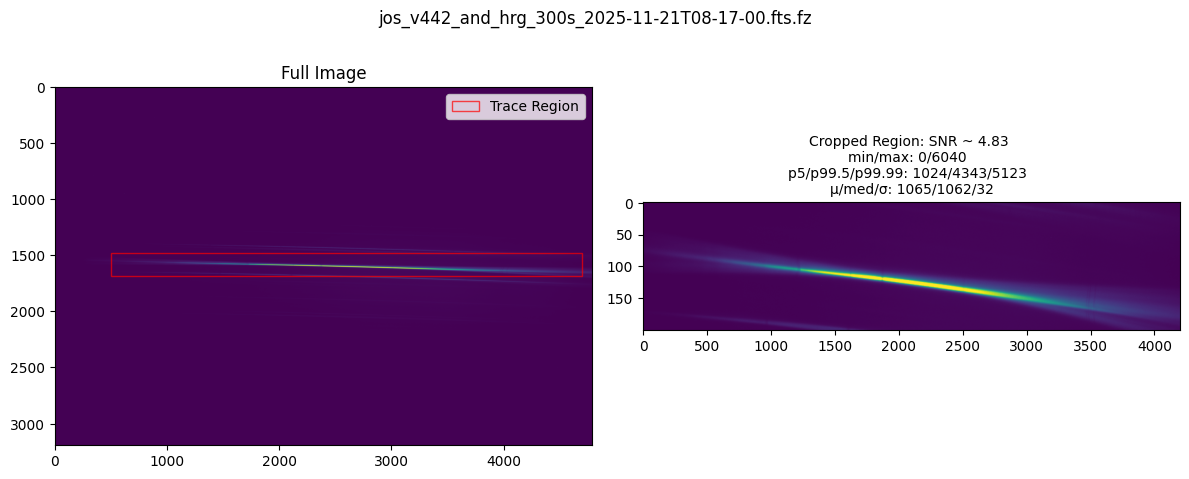

In [122]:
from matplotlib.patches import Rectangle
from astropy.stats import sigma_clipped_stats

i_start = 0
i_end = 1 # First i_end - 1 images
# i_end = len(img_files) # All images

for grism_image in img_files[i_start:i_end]:

    if filter == 'hrg':
        xstart = 500
        ystart = 1580
        xwidth = 4200
        ywidth = 200
    
    if filter == 'lrg':
        xstart = 1450
        ystart = 1760
        xwidth = 2500
        ywidth = 200

    print(grism_image)

    image_data = fits.getdata(grism_image)

    ymin = ystart - int(ywidth/2)
    ymax = ystart + int(ywidth/2)

    # Crop region
    cropped_image_data = image_data[
        ymin: ymax,
        xstart : xstart + xwidth
    ]

    # --- Statistics ONLY on cropped region ---
    mean_sc, med_sc, std_sc = sigma_clipped_stats(
        cropped_image_data, sigma=3.0, maxiters=5
    )

    vmin_p, vmax_p = np.percentile(cropped_image_data, (5, 99.5))
    p9999 = np.percentile(image_data, 99.99)
    dmin = float(np.nanmin(cropped_image_data))
    dmax = float(np.nanmax(cropped_image_data))

    # --- Create figure with two panels ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------- Left: full image --------
    ax_full = axes[0]
    ax_full.imshow(
        image_data,
        cmap="viridis",
        vmin=vmin_p,
        vmax=vmax_p
    )
    ax_full.set_title("Full Image")

    rect = Rectangle(
        (xstart, ymin),
        xwidth,
        ywidth,
        facecolor='none',
        edgecolor='red',
        alpha=0.7,
        label='Trace Region'
    )
    ax_full.add_patch(rect)
    ax_full.legend()

    # -------- Right: cropped image --------
    ax_crop = axes[1]
    ax_crop.imshow(
        cropped_image_data,
        cmap="viridis",
        vmin=vmin_p,
        vmax=vmax_p
    )

    # Stats shown as the title (no overlap possible)
    stats_title = (
        f"Cropped Region: SNR ~ {p9999 / med_sc:.2f} \n"
        f"min/max: {dmin:.0f}/{dmax:.0f}  \n"
        f"p5/p99.5/p99.99: {vmin_p:.0f}/{vmax_p:.0f}/{p9999:.0f}  \n"
        f"μ/med/σ: {mean_sc:.0f}/{med_sc:.0f}/{std_sc:.0f}"
    )
    ax_crop.set_title(stats_title, fontsize=10)
    ax_crop.set_aspect(5)

    # Figure title
    fig.suptitle(grism_image.split("/")[-1])

    plt.tight_layout()
    plt.show()

##  (Optional) Calculate Radial Velocity Wavelength Corrections

In [123]:
# Query Simbad for the recessional velocity of the target

!pip3 install astroquery

from astroquery.simbad import Simbad

# Reset to default fields
Simbad.reset_votable_fields()

# List available votable fields
print("Available votable fields:")
print(Simbad.list_votable_fields())

Simbad.add_votable_fields('rvz_radvel')

star_name = targets[0]
result_table = Simbad.query_object(star_name)

if result_table is None:
    print(f"No results found for {star_name}.")
else:
    print("Returned columns:", result_table.colnames)

    if 'rvz_radvel' in result_table.colnames:
        rv = result_table['rvz_radvel'][0]
        if rv is None:
            print('')
            print(f"No radial (recessional) velocity available for {star_name}.")
            print('')
        else:
            print('')
            print(f"The radial (recessional) velocity of {star_name} is {rv} km/s.")
            print('')
    else:
        print("Radial velocity column not found in the result. Available columns are:")
        print(result_table.colnames)

Available votable fields:
    name    ...     type   
----------- ... -----------
mesDiameter ...       table
      mesPM ...       table
     mesISO ...       table
     mesSpT ...       table
  allfluxes ...       table
      ident ...       table
       flux ...       table
   mesOtype ...       table
     mesPLX ...       table
   otypedef ...       table
        ... ...         ...
          K ... filter name
          u ... filter name
          g ... filter name
          r ... filter name
          i ... filter name
          z ... filter name
          G ... filter name
      F150W ... filter name
      F200W ... filter name
      F444W ... filter name
Length = 116 rows
Returned columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'rvz_radvel', 'matched_id']

The radial (recessional) velocity of V442_And is -55.0 km/s.



In [124]:
# Calculate earth + target recessional velocity corrections with astropy for rigel based on DATE-OBS in header

target_velocity = rv*u.km/u.s
radial_velocities = []
wavelength_corrections = []
times = []

target_name = targets[0].replace('_', ' ')

for i in range(len(img_files)):
  # Get the DATE-OBS from the header
  hdu = fits.open(img_files[i])
  hdul = hdu[1].header
  date_obs = hdul['DATE-OBS']
  # print(date_obs)

  # Should really pull the target from the header...
  target_star = SkyCoord.from_name(target_name)
  # print(target)

  # Get the observatory location
  obs_loc = EarthLocation.of_site('Winer')
  # print(obs_loc)

  # Convert date_obs to astropy time
  t = Time(date_obs, format='isot', scale='utc', location=obs_loc)
  times.append(t)
  # print(t)

  radial_vel_correction = target_star.radial_velocity_correction(obstime=t).to('km/s')
  # print("Earth motion velocity: ", radial_vel_correction)
  # print("Target velocity: ", target_velocity)

  c = 299792.458 * u.km/u.s  # Speed of light in km/s
  wavelength_correction = 1 + (radial_vel_correction + target_velocity) / c
  # print("Total Radial Velocity", radial_vel_correction + target_velocity)
  # print("Wavelength correction: ", wavelength_correction)

  radial_velocities.append(radial_vel_correction + target_velocity)
  wavelength_corrections.append(wavelength_correction)

for i in range(len(radial_velocities)):
  print(f'Date and Time of Observation: {times[i]}')
  print(f'Radial Velocity Correction: {radial_velocities[i]}')
  print(f'Wavelength Correction: {wavelength_corrections[i]}')
  if wavelength_corrections[i] < 1:
    print('Light is blue shifted')
  else:
    print('Light is red shifted')
  print('')

Date and Time of Observation: 2025-11-21T08:16:59.950
Radial Velocity Correction: -64.97166102037389 km / s
Wavelength Correction: 0.9997832778667822
Light is blue shifted

Date and Time of Observation: 2025-11-21T08:32:14.930
Radial Velocity Correction: -64.9846842383465 km / s
Wavelength Correction: 0.999783234426003
Light is blue shifted

Date and Time of Observation: 2025-11-24T07:42:12.280
Radial Velocity Correction: -66.09077270123863 km / s
Wavelength Correction: 0.9997795449120297
Light is blue shifted

Date and Time of Observation: 2025-11-24T07:47:17.200
Radial Velocity Correction: -66.09568348816258 km / s
Wavelength Correction: 0.9997795285314077
Light is blue shifted

Date and Time of Observation: 2025-11-24T08:07:24.950
Radial Velocity Correction: -66.11407938856159 km / s
Wavelength Correction: 0.999779467169289
Light is blue shifted

Date and Time of Observation: 2025-11-25T07:58:59.970
Radial Velocity Correction: -66.48347059621352 km / s
Wavelength Correction: 0.99977

## Import and Update Calibration Solutions

In [125]:
# Import existing calibration spectra class objects from pickles

ZWO_calib_spectra = restore_spectrum_objects_from_pickle(
    f"Calib_Spectra_{filter}_ZWO.pkl",
    spectrum
)

QHY_calib_spectra = restore_spectrum_objects_from_pickle(
    f"Calib_Spectra_{filter}_QHY.pkl",
    spectrum
)

In [126]:
# Bin calibration spectra and match to science images
matches = match_science_to_calib(
    img_files,
    calib_img_files,
    tbin=900,
    verbose=True # set verbose=False to suppress summary printout
) 


Calibration bin summary
-----------------------
Found 16 calibration bins
Calibration date range available: 2025-12-05T12:27:51.320  →  2026-05-07T04:09:27.180
Total calibration images available: 251
Science images: 147
Bin width criterion: 900 s (15.0 min)

Bin 00: 6 calibration file(s), 2025-12-05T12:27:51.320 → 2025-12-05T12:30:43.570, rep = jos_hr_3454_hrg_30s_2025-12-05T12-18-35.fts.fz
  Calibration files:
    - jos_hr_3454_hrg_15s_2025-12-05T12-17-55.fts.fz  [2025-12-05T12:27:51.320]
    - jos_hr_3454_hrg_15s_2025-12-05T12-18-15.fts.fz  [2025-12-05T12:28:10.690]
    - jos_hr_3454_hrg_30s_2025-12-05T12-18-35.fts.fz  [2025-12-05T12:28:30.200]
    - jos_hr_3454_hrg_30s_2025-12-05T12-19-10.fts.fz  [2025-12-05T12:29:04.570]
    - jos_hr_3454_hrg_60s_2025-12-05T12-19-45.fts.fz  [2025-12-05T12:29:39.140]
    - jos_hr_3454_hrg_60s_2025-12-05T12-20-50.fts.fz  [2025-12-05T12:30:43.570]
  Science images:
    - jos_v442_and_hrg_300s_2025-11-21T08-17-00.fts.fz
    - jos_v442_and_hrg_300s_202

In [127]:
# 1) Derive any missing calibration spectra and update the stored lists
update_result = ensure_required_calib_spectra(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class=spectrum,
    filter=filter,
    save_updated=True,
    zwo_pkl=f"Calib_Spectra_{filter}_ZWO.pkl",
    qhy_pkl=f"Calib_Spectra_{filter}_QHY.pkl",
    verbose=True
)

ZWO_calib_spectra = update_result["ZWO_calib_spectra"]
QHY_calib_spectra = update_result["QHY_calib_spectra"]

# 2) Build one averaged calibration object per bin (mean averaging of wavelength and gain solutions in each bin)
bin_avg_lookup = build_bin_averaged_calibrations(
    matches,
    ZWO_calib_spectra,
    QHY_calib_spectra,
    spectrum_class=spectrum,
    verbose=True
)

# 3) Attach the averaged calibration objects to each science-image match row
matches = attach_bin_averaged_calibrations_to_science_matches(
    matches,
    bin_avg_lookup,
    fallback = True,
    verbose = True
)

Saved 295 objects to Calib_Spectra_hrg_ZWO.pkl
Saved 201 objects to Calib_Spectra_hrg_QHY.pkl

Saved updated ZWO calibration list -> Calib_Spectra_hrg_ZWO.pkl
Saved updated QHY calibration list -> Calib_Spectra_hrg_QHY.pkl

Averaged calibration summary
----------------------------
Science-relevant calibration bins found: 16
Averaged calibration objects built:      16
Bins that failed to build:               0
Calibration images used in bin averages: 62
Flagged calibration entries skipped:     0
Calibration images newly derived:        0
  ZWO appended:                          0
  QHY appended:                          0
  Newly derived but flagged:             0

Science calibration assignment summary
--------------------------------------
Successful calibration bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Science images reassigned by fallback: 0


## Extract + Calibrate Science Spectra

In [ ]:
spectra = []

science_matches = matches["science_matches"]

for i, row in enumerate(science_matches):
    grism_image = row["science_file"]
    match = row.get("averaged_calib_spectrum", None)

    try:
        if match is None:
            raise ValueError("No averaged calibration spectrum assigned.")

        S = spectrum(grism_image, calib_spectrum=match, filter=filter)

        print('')
        print(f'Processing image {i + 1} of {len(science_matches)}: {S.object_name} {S.obs_date} ({S.exp_time} s):')
        print('')
        try:
            trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = False, curved=True, method = 'gauss')
        except Exception as e:
            print('Failed to fit trace with gauss method, defaulting to max method')
            trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = False, curved=True, method = 'max')
        spec = S.extract_spectrum(
            show_box=False,
            plot=False,
            curved_box=True
        )
        telluric_pixel = S.fit_telluric(plot=False)
        # telluric_pixel = S.fit_telluric(x_guess = 2940, plot = True, debugging = False, manual_override = True) # Use this line instead if you want to manually override the telluric fit
        waves = S.wavelength_calibrate(plot=False)
        cal_spec = S.gain_calibrate(plot=False)

        spectra.append(S)

    except Exception as e:
        print(f"Failed on {os.path.basename(grism_image)}: {e}")
        try:
            S.flagged = True
            spectra.append(S)
        except:
            pass
        continue


Processing image 1 of 147: v442 and 2025-11-21 08:16:59.95 (300.0 s):


Processing image 2 of 147: v442 and 2025-11-21 08:32:14.93 (300.0 s):


Processing image 3 of 147: v442 and 2025-11-24 07:42:12.28 (300.0 s):

Failed on jos_v442_and_hrg_300s_2025-11-24T07-32-00.fts.fz: Telluric fit failed redchi threshold: 0.10506 > 0.005

Processing image 4 of 147: v442 and 2025-11-24 07:47:17.20 (300.0 s):

Failed on jos_v442_and_hrg_300s_2025-11-24T07-37-05.fts.fz: Telluric fit failed redchi threshold: 0.33685 > 0.005

Processing image 5 of 147: v442 and 2025-11-24 08:07:24.95 (300.0 s):

Failed on jos_v442_and_hrg_300s_2025-11-24T07-52-20.fts.fz: Telluric fit failed redchi threshold: 0.037821 > 0.005

Processing image 6 of 147: V442 And 2025-11-25 07:58:59.97 (300.0 s):


Processing image 7 of 147: V442 And 2025-11-25 08:05:15.44 (300.0 s):


Processing image 8 of 147: V442 And 2025-11-25 08:11:30.92 (300.0 s):


Processing image 9 of 147: V442 And 2025-11-25 08:17:46.48 (300.0 s):


Processi

In [ ]:
tel_fit_geometry = []
dates = [S.obs_date for S in spectra]

for S in spectra:
    try:
        tel_result = S.telluric_fit_result
        params = tel_result.params
        cen1 = params['cen1'].value
        sep = params['sep'].value
        cen2 = cen1 + sep
        fwhm1 = 2.354820045 * params['sig1'].value
        fwhm2 = 2.354820045 * params['sig2'].value
        amp1 = params['amp1'].value
        amp2 = params['amp2'].value
        tel_fit_geometry.append({
            'cen1': cen1,
            'cen2': cen2,
            'sep': sep,
            'fwhm1': fwhm1,
            'fwhm2': fwhm2,
            'amp1': amp1,
            'amp2': amp2
        })
    except:
        continue

In [ ]:
import pandas as pd

tel_df = pd.DataFrame([
    {
        'camera': getattr(S, 'camera', None),
        'cen1': p['cen1'].value,
        'cen2': p['cen1'].value + p['sep'].value,
        'sep': p['sep'].value,
        'fwhm1': 2.354820045 * p['sig1'].value,
        'fwhm2': 2.354820045 * p['sig2'].value,
        'amp1': p['amp1'].value,
        'amp2': p['amp2'].value,
    }
    for S in spectra
    if hasattr(S, 'telluric_fit_result')
    for p in [S.telluric_fit_result.params]
])

stats = tel_df.groupby('camera').agg(['mean', 'median', 'std'])

print(stats)

                  cen1                                 cen2               \
                  mean       median        std         mean       median   
camera                                                                     
ASI Camer  3062.160294  3068.918849  14.858647  3099.254935  3105.178928   

                           sep                          fwhm1  ...            \
                std       mean    median       std       mean  ...       std   
camera                                                         ...             
ASI Camer  14.36331  37.094641  36.98814  1.908649  22.367323  ...  1.618265   

                fwhm2                            amp1                      \
                 mean      median       std      mean    median       std   
camera                                                                      
ASI Camer  133.476156  134.297463  8.003346 -0.123198 -0.123027  0.006443   

               amp2                      
               mean    

In [ ]:
tel_df

,camera,cen1,cen2,sep,fwhm1,fwhm2,amp1,amp2
0,ASI Camer,3073.606836,3109.260920,35.654084,21.318591,132.204127,-0.134754,-0.129358
1,ASI Camer,3074.211476,3110.637607,36.426131,21.599930,130.664059,-0.140601,-0.132354
2,ASI Camer,3076.404804,3114.157642,37.752838,21.879401,129.503044,-0.136839,-0.128163
3,ASI Camer,3076.443045,3113.065967,36.622922,21.439869,127.869346,-0.136589,-0.129828
4,ASI Camer,3078.406312,3114.518710,36.112398,21.535931,128.196117,-0.137406,-0.130156
...,...,...,...,...,...,...,...,...
137,ASI Camer,3077.452748,3113.948534,36.495786,24.537812,135.461711,-0.121740,-0.121740
138,ASI Camer,3080.238500,3115.378260,35.139760,23.906351,130.253289,-0.119190,-0.119190
139,ASI Camer,3078.556157,3115.010707,36.454551,23.695383,127.534076,-0.130314,-0.130314
140,ASI Camer,3079.105846,3116.264551,37.158705,24.323158,127.079153,-0.129787,-0.129787


In [ ]:
# QQ Gem

#                   cen1                                 cen2               \
#                   mean       median        std         mean       median  
# camera                                                                     
# ASI Camer  3069.018153  3066.875064  11.831710  3103.721151  3101.423206   
# QHYCCD-Ca  2987.960452  2988.954833   5.263621  3026.676905  3025.003534   

#                             sep                           fwhm1  ...  \
#                  std       mean     median       std       mean  ...   
# camera                                                           ...   
# ASI Camer  12.833836  34.702999  34.855049  2.178235  22.213208  ...   
# QHYCCD-Ca   4.418416  38.716453  36.612716  4.650685  23.262768  ...   

#                           fwhm2                             amp1            \
#                 std        mean      median        std      mean    median   
# camera                                                                       
# ASI Camer  2.310333  135.714404  132.728215  12.248137 -0.115461 -0.116246   
# QHYCCD-Ca  3.733405   72.740963   70.688775   5.595370 -0.154498 -0.154112   

#                          amp2                      
#                 std      mean    median       std  
# camera                                             
# ASI Camer  0.010286 -0.123105 -0.123768  0.010770  
# QHYCCD-Ca  0.020826 -0.101122 -0.101123  0.005843  

# RY Sct

#                   cen1                                cen2              \
#                   mean       median       std         mean      median   
# camera                                                                   
# ASI Camer  3060.867785  3060.621939  1.719510  3092.333717  3091.41368   
# QHYCCD-Ca  2971.788520  2970.907752  4.375396  3009.829788  3007.60044   

#                            sep                           fwhm1  ...            \
#                 std       mean     median       std       mean  ...       std   
# camera                                                          ...             
# ASI Camer  2.844587  31.465931  31.336925  2.086086  21.262983  ...  1.533038   
# QHYCCD-Ca  6.130487  38.041269  36.261710  5.287263  21.739763  ...  2.207174   

#                fwhm2                           amp1                      \
#                 mean     median       std      mean    median       std   
# camera                                                                    
# ASI Camer  87.854204  91.102936  7.991769 -0.149917 -0.146936  0.018174   
# QHYCCD-Ca  62.730040  61.616443  7.233420 -0.178538 -0.170122  0.019177   

#                amp2                      
#                mean    median       std  
# camera                                   
# ASI Camer -0.148212 -0.147003  0.007698  
# QHYCCD-Ca -0.105528 -0.108300  0.011082  

# [2 rows x 21 columns]

# Bet CMi

#                   cen1                                 cen2               \
#                   mean       median        std         mean       median   
# camera                                                                     
# ASI Camer  3065.138847  3060.475899  12.516474  3105.763745  3101.061660   
# QHYCCD-Ca  2985.596624  2987.380071   8.874834  3023.462388  3025.439188   

#                             sep                           fwhm1  ...  \
#                  std       mean     median       std       mean  ...   
# camera                                                           ...   
# ASI Camer  14.714716  40.624898  39.361495  3.172638  21.111966  ...   
# QHYCCD-Ca  10.188177  37.865763  38.049026  1.364832  21.405376  ...   

#                           fwhm2                             amp1            \
#                 std        mean      median        std      mean    median   
# camera                                                                       
# ASI Camer  0.660965  159.094671  160.319699  16.317472 -0.120184 -0.120097   
# QHYCCD-Ca  0.293430   76.174140   78.941503   8.569132 -0.155320 -0.147120   

#                          amp2                      
#                 std      mean    median       std  
# camera                                             
# ASI Camer  0.011519 -0.147305 -0.146869  0.012728  
# QHYCCD-Ca  0.028791 -0.091893 -0.095078  0.007158  

# [2 rows x 21 columns]

# How does calibration work?

Single cell iteration example of deriving calibration solutions and applying them to a science spectrum

ASI Camera (1)
Moon Angle & Phase: 98.95 degrees, 99.92 %


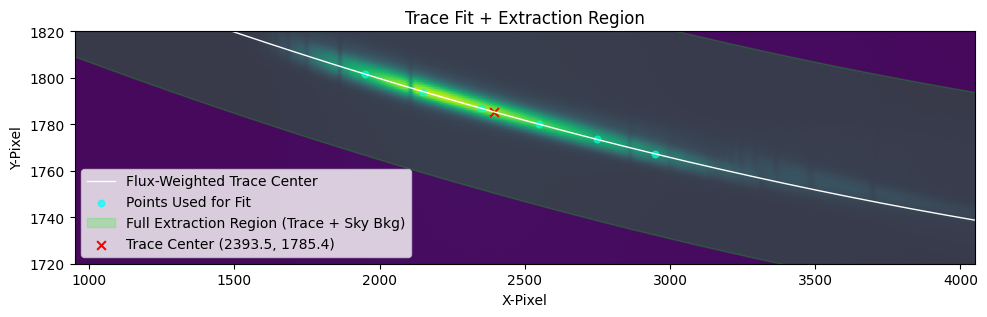

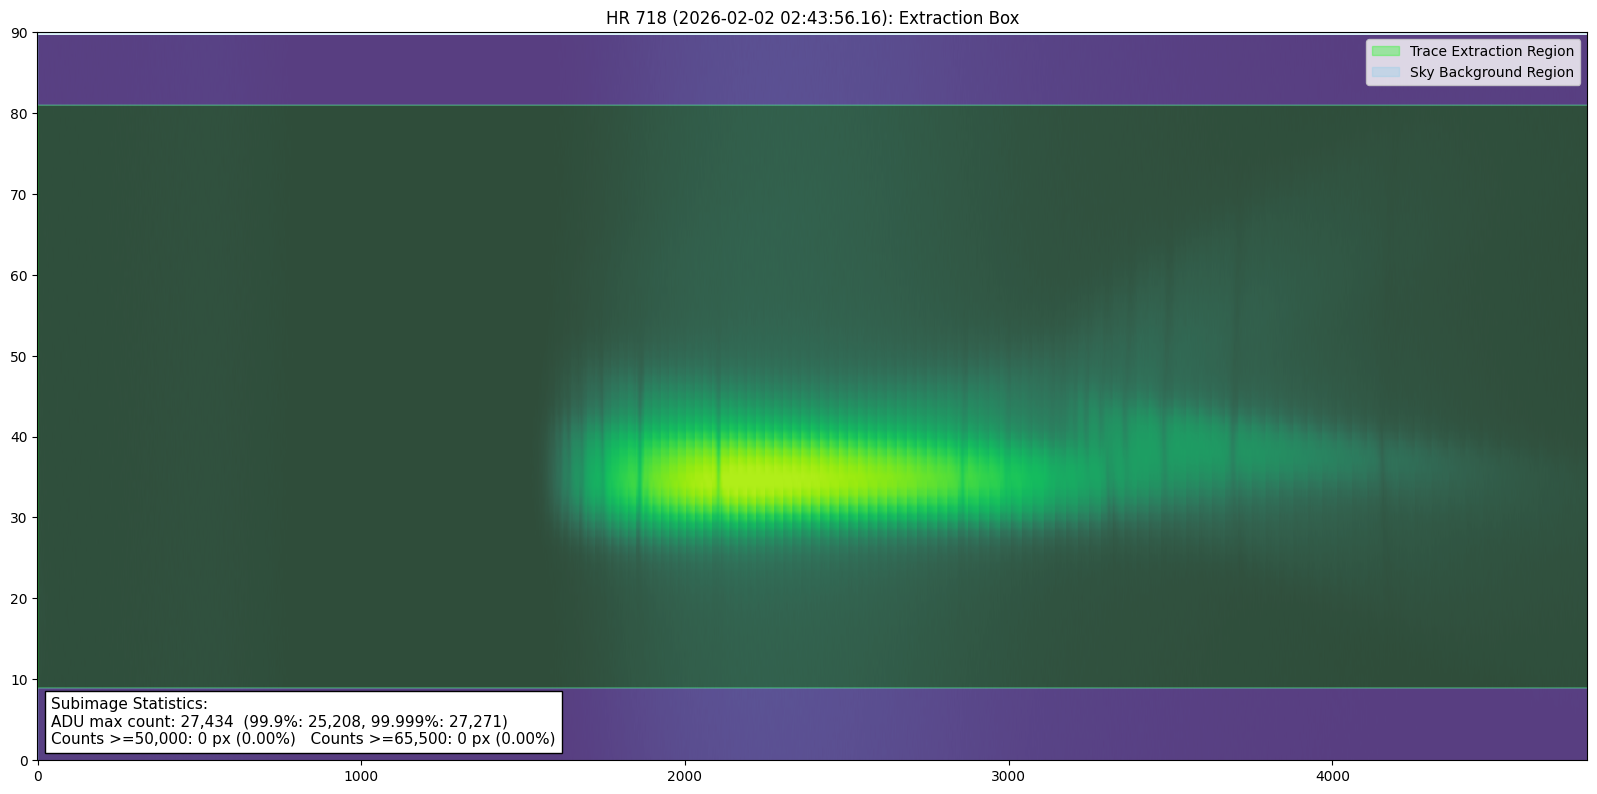

/Users/joshuamarine/Desktop/Code/Be-Stars/grism_utils_v2.py:1350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


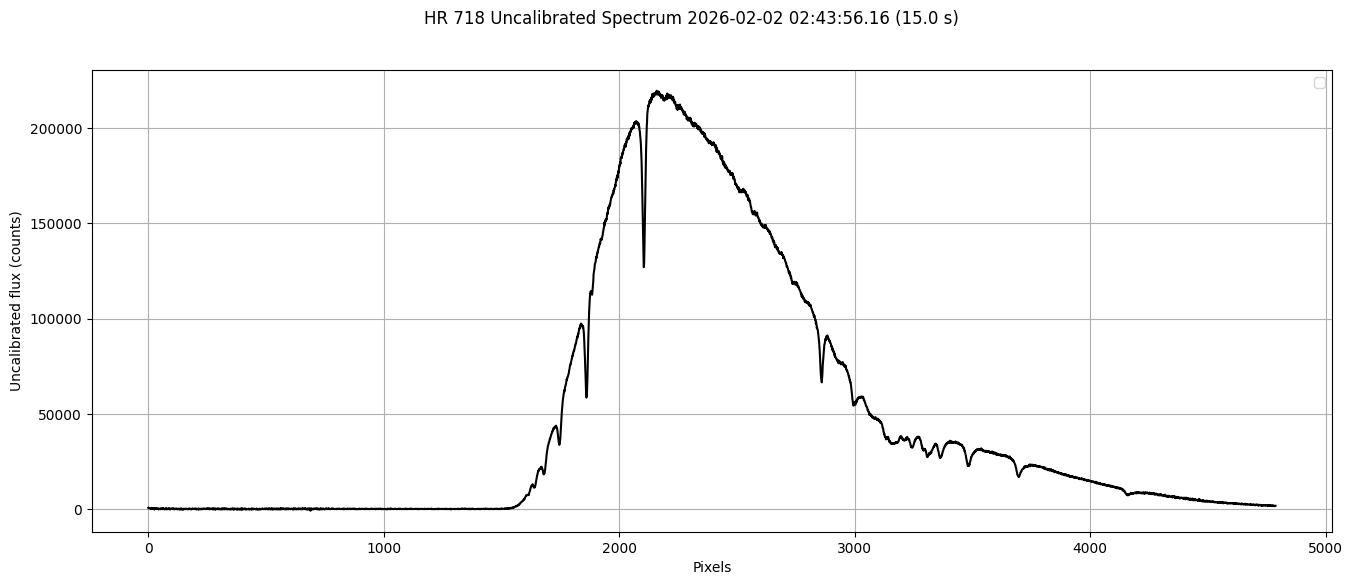

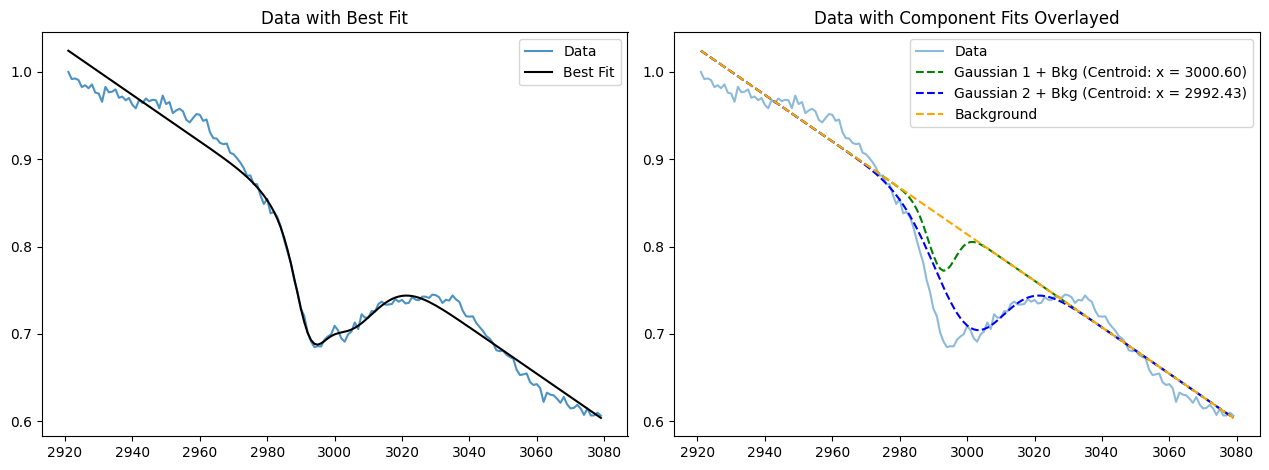

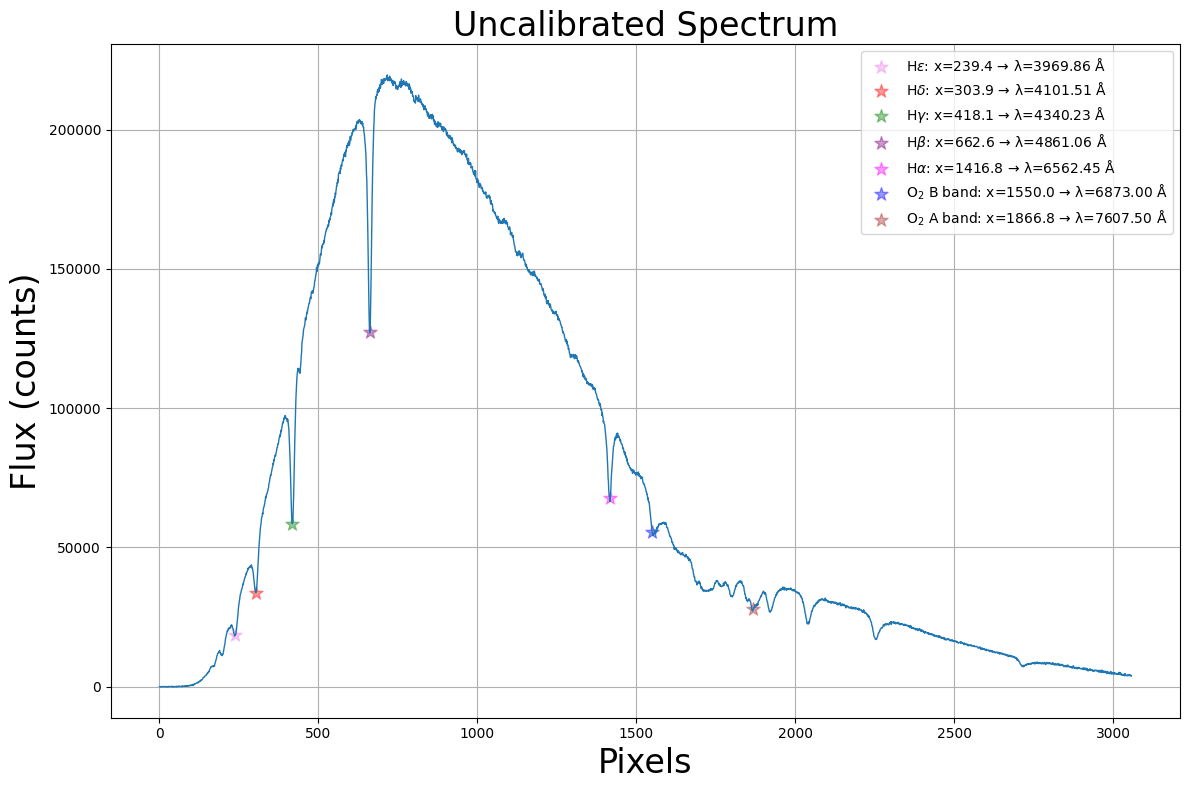

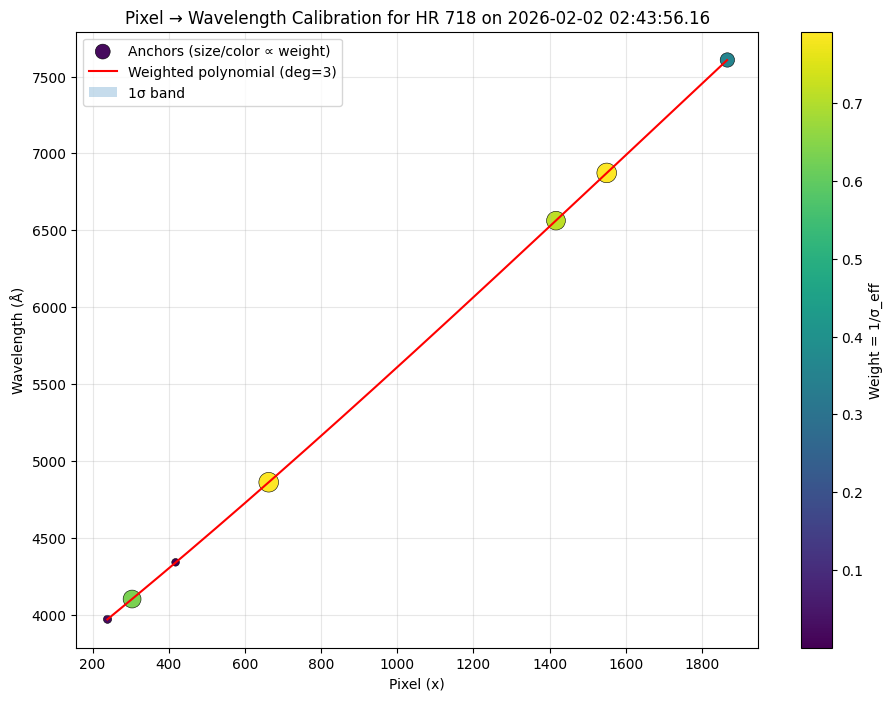

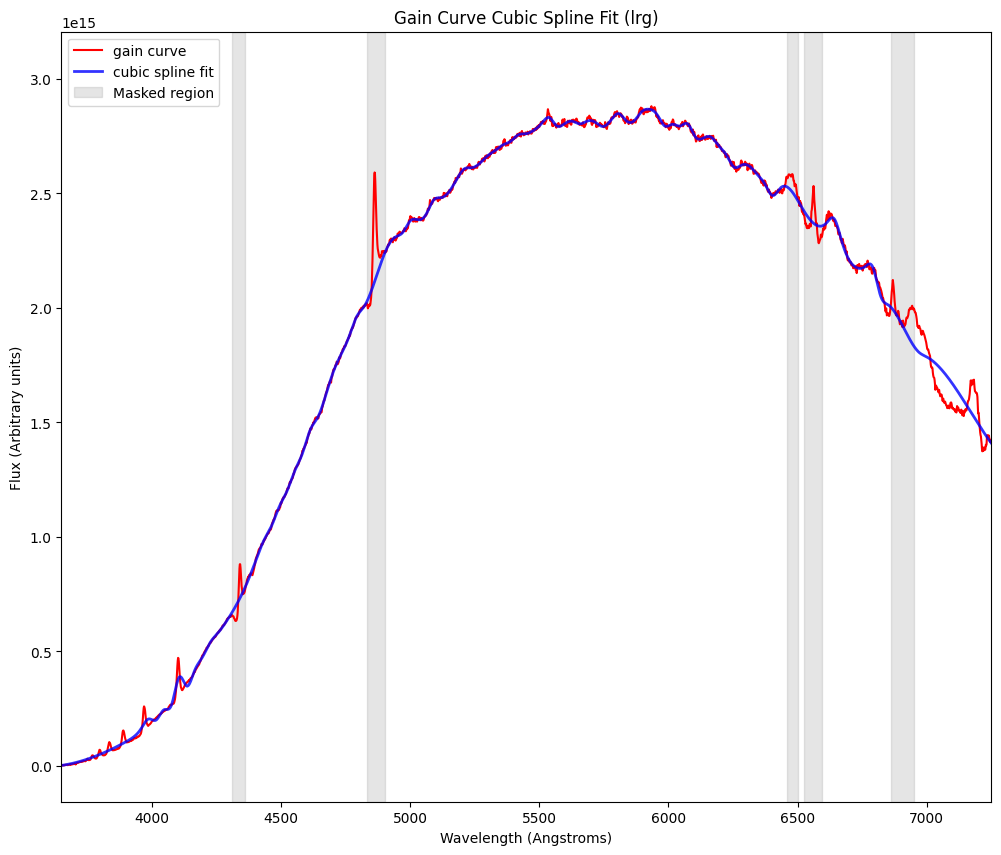

In [ ]:
# Demonstrative calibration derivation example

i = 30

S = spectrum(calib_img_files[i], calib_spectrum = None, filter = filter, calib_img = True)

print(S.hdr['INSTRUME'])
print(f'Moon Angle & Phase: {S.moonangle:.2f} degrees, {(S.moonphase * 100):.2f} %')

trace_center, cutouts, subim = S.fit_trace(plot = True, curved = True, show_points = True, method = 'gauss')
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True)
telluric_pixel = S.fit_telluric(plot = True, debugging = False)
wavelength_correction = S.derive_wavelength_correction()
wave_calib = S.derive_wavelength_solution(show_points = True, plot = True)
waves = S.wavelength_calibrate()
ref_wave, ref_flux = S.load_stelib_spectrum('STELIB')
wave_grid, flux_data_interp, flux_ref_interp = S.match_and_interpolate()
gain_curve = S.derive_gain_calibration(plot = True)

# for key, value in vars(S).items():
#     print(f"{key}: {type(value)}")

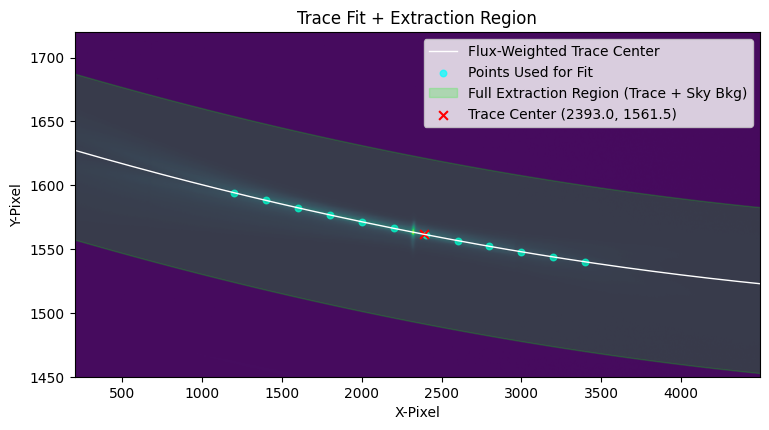

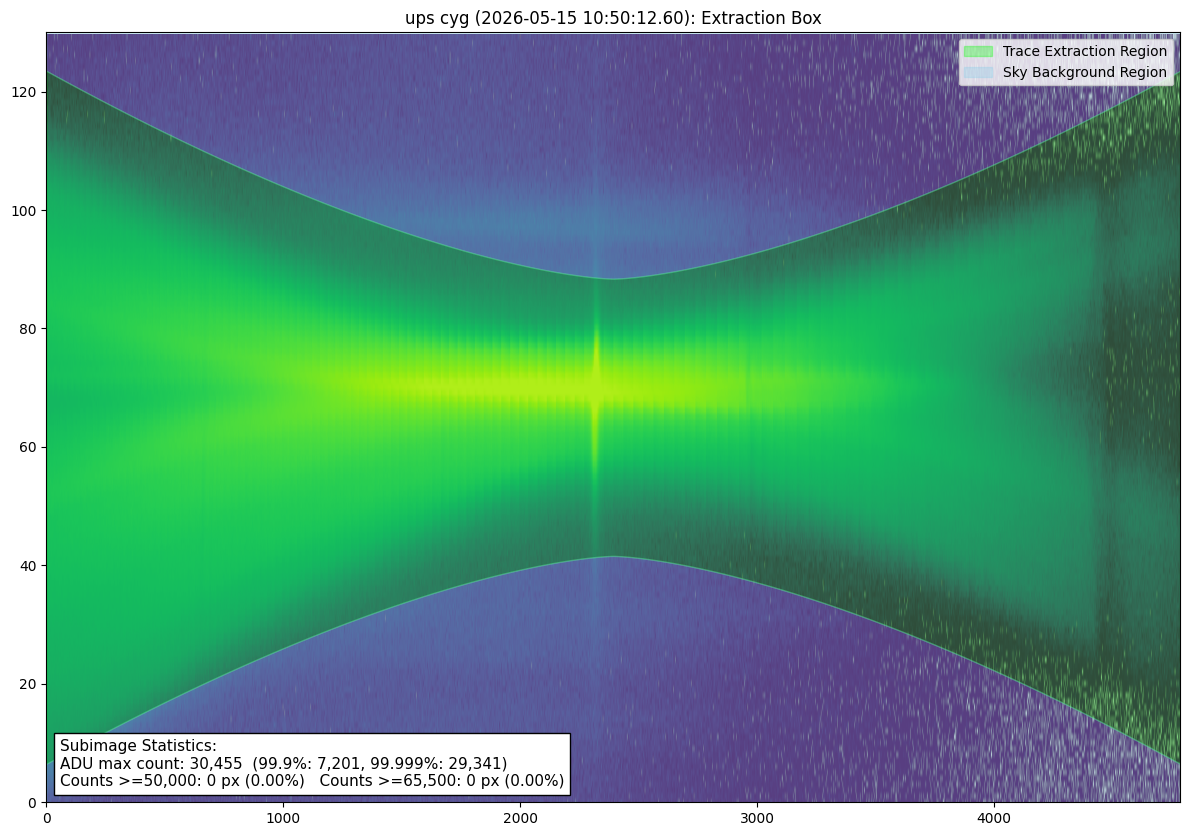

/Users/joshuamarine/Desktop/Code/Be-Stars/grism_utils_v2.py:1350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


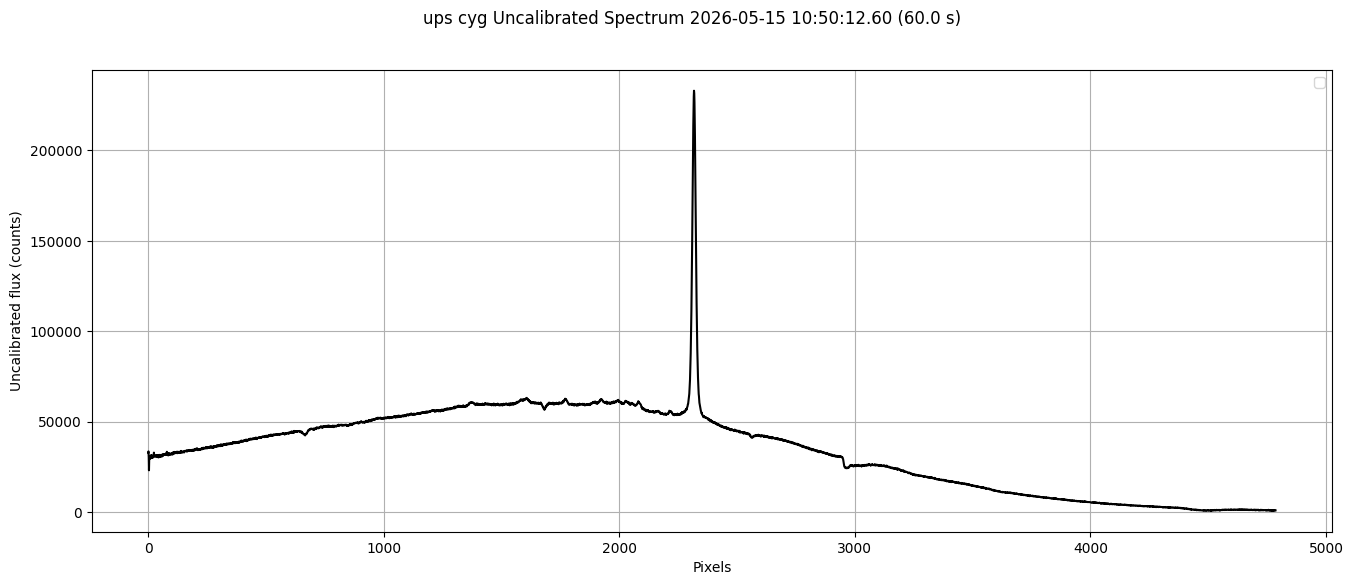

Fit Parameters:
  Left Gaussian FWHM: 21.37 pixels
  Left Gaussian Centroid: x = 2964.57
 Left Gaussian Amplitude: -0.13
 Right Gaussian Amplitude: -0.09
  Right Gaussian FWHM: 78.95 pixels
  Right Gaussian Centroid: x = 3004.15

  Left Centroid Fit Value - Left Centroid Data Value [y]: 0.0210
  Centroid Difference [x]: 39.58
  Centroid Height Difference (right - left) [y]: 0.0466


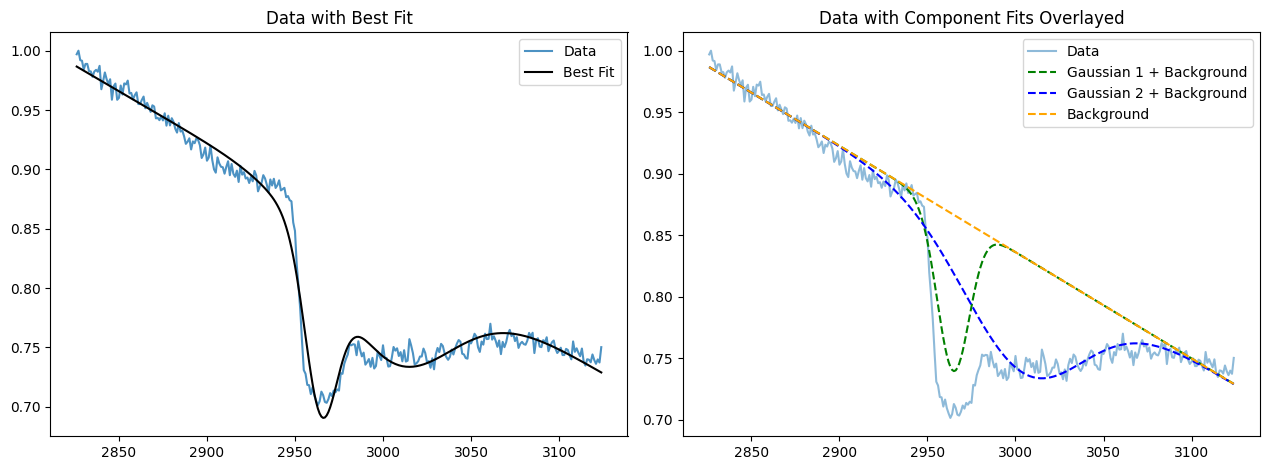

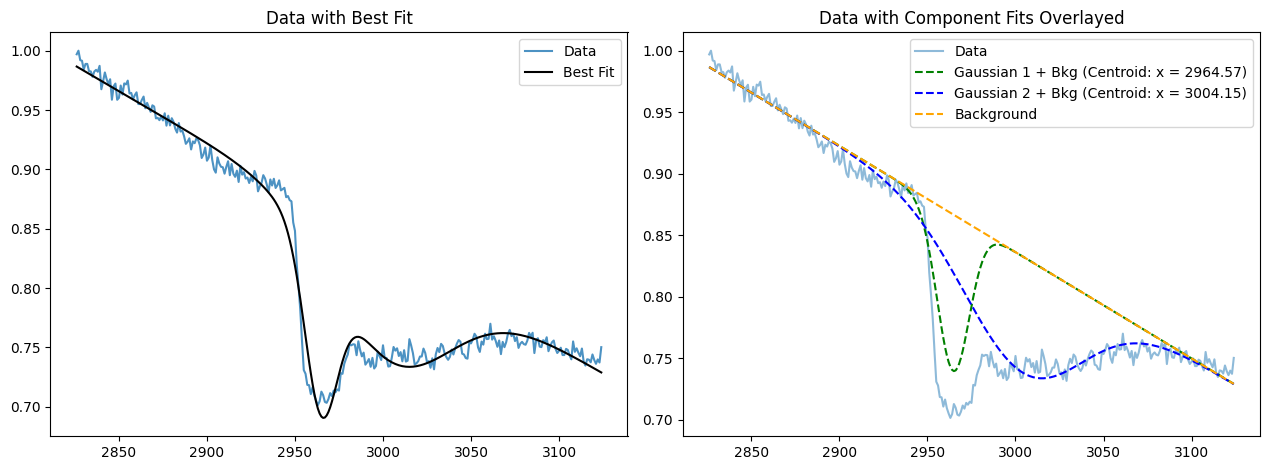

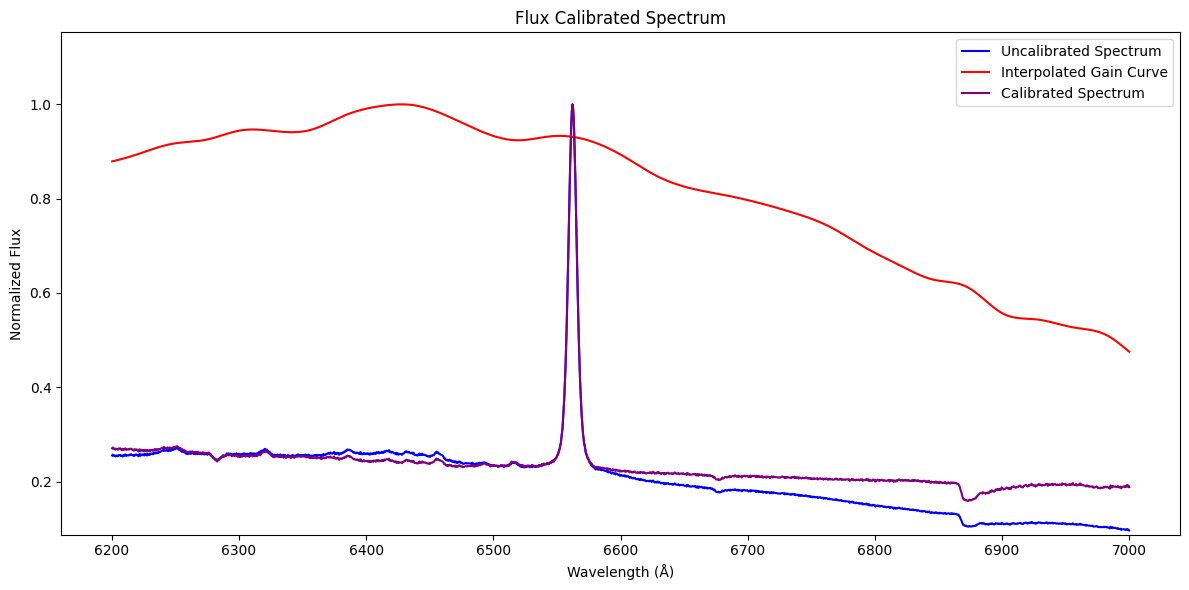

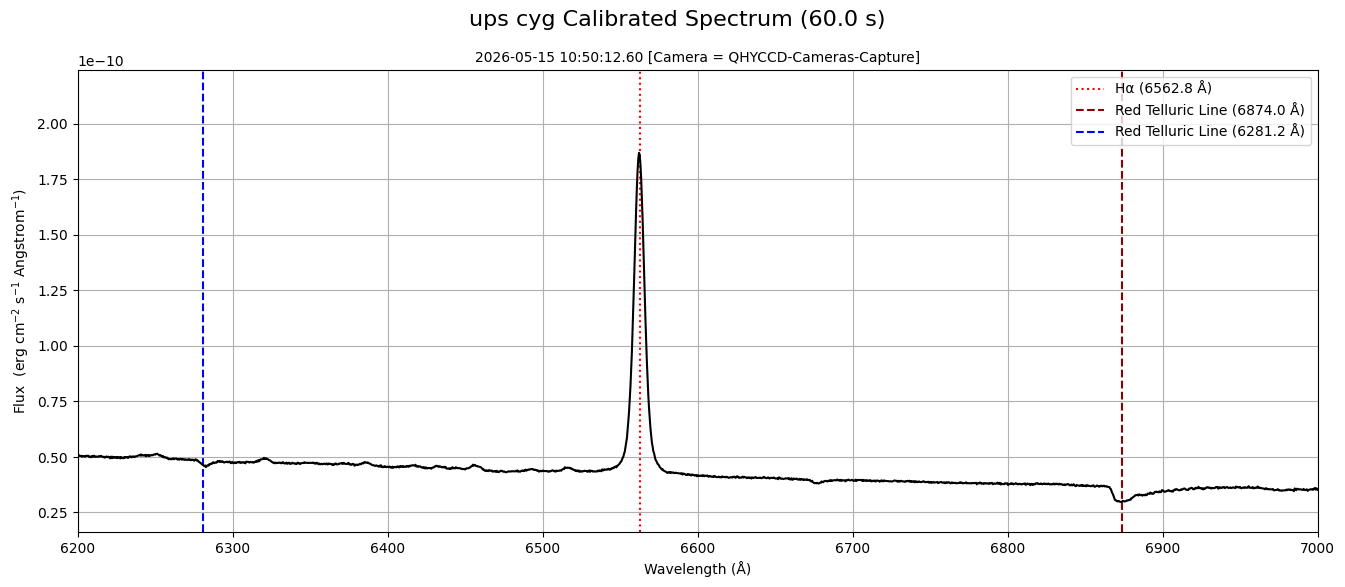

In [ ]:
i = 10

calib_img = matches['science_matches'][i].get("averaged_calib_spectrum", None)
grism_image = matches['science_matches'][i]["science_file"]

S = spectrum(grism_image, calib_spectrum=calib_img, filter=filter)

# print(f'Moon Angle & Phase: {S.moonangle:.2f} degrees, {(S.moonphase * 100):.2f} %')
S.remove_hot_pixels()
try:
    trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'gauss') # can try method = 'gauss' if fitting poorly
except Exception as e:
    trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'max') # can try method = 'gauss' if fitting poorly
# trace_center, cutouts, subim = S.fit_trace(plot = True, show_points = True, curved = True, method = 'gauss')
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True, sat_level = None)
# telluric_pixel = S.fit_telluric(x_guess = None, plot = True, debugging = True)
telluric_pixel = S.fit_telluric_old(x_guess = None, plot = True, debugging = True, manual_override = False)
# print(telluric_pixel)
waves = S.wavelength_calibrate(plot = False)
cal_spec = S.gain_calibrate(plot = True)
fig = S.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True)

# All Done!

Now let's output a pdf file of the results

In [ ]:
# Wrap all class functions into parent function that can have input parameters of select indices for manual entry or things like that
# Have function output flagged spectra to rerun
# Run parent function in for loop for all targets to process all data
# Save final data as csv with column entries for telluric pixel entry 
# Create conditional to pull from existing csv or default if not csv
# Create manual entry conditional for if CSV already exists then do/don't overwrite
# Anytime you're reusing the same thing/attribute you want to possibly split that into different classes
  # This way if you make changes it propagates through fluidly
# For averaging, reinitialize spectrum class with only necessary attributes
# Initialize new class structure for output calibration parameters applied to science spectra

# Make sure all science spectra have calibration spectra assigned to them

# ffmpeg
# matplotlib funcanimation

In [ ]:
# !!! Please paste in your last name here for saving output files !!!
username = 'Marine'


out_folder = os.path.expanduser('~/Desktop/Code/calibrated_data/')
gdrive_out_folder = drive_path + '/calibrated_data/'

if os.path.exists(out_folder) and os.path.isdir(out_folder) and os.path.isdir(gdrive_out_folder):
    print("Directories exist, you're good to go!")
else:
    print("Directories do not exist, change your directories")

Directories exist, you're good to go!


## (Optional) Look at Final Spectra

In [ ]:
# Show all the spectra again

for i in range(len(spectra)):
  spec = spectra[i]
  if spec.flagged:
    print(f'Skipping spectrum {i+1} of {len(spectra)}: {spec.grism_image} (Flagged)')
    continue
  print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')
  print(f'Moon Angle & Phase: {spec.moonangle:.2f} degrees, {(spec.moonphase * 100):.2f} %')
  print(f'Telluric Line Pixel: {spec.telluric_pixel:.2f}')

  # fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True)

Processing spectrum 1 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-17-00.fts.fz
Moon Angle & Phase: 134.68 degrees, 1.21 %
Telluric Line Pixel: 3073.61
Processing spectrum 2 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-32-15.fts.fz
Moon Angle & Phase: 134.57 degrees, 1.23 %
Telluric Line Pixel: 3074.21
Skipping spectrum 3 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-32-00.fts.fz (Flagged)
Skipping spectrum 4 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-37-05.fts.fz (Flagged)
Skipping spectrum 5 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-52-20.fts.fz (Flagged)
Processing s

## Save CSVs and PDFs Locally

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

# Define the output PDF file
pdf_filename = out_folder + f"{username}_{targets[0]}_{filter}_calibrated_spectra.pdf"

# Check if the file exists and notify about overwriting
if os.path.exists(pdf_filename):
    print(f"The file '{pdf_filename}' already exists and will be overwritten.")

# Create a PDF object to store plots
with PdfPages(pdf_filename) as pdf:
    for i in range(len(spectra)):
        spec = spectra[i]
        print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')

        if spec.flagged:
            continue

        fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True, show = False)

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.close()  # Close the plot to free memory

print(f"All plots saved to {pdf_filename}")

The file '/Users/joshuamarine/Desktop/Code/calibrated_data/Marine_V442_And_hrg_calibrated_spectra.pdf' already exists and will be overwritten.
Processing spectrum 1 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-17-00.fts.fz
Processing spectrum 2 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-32-15.fts.fz
Processing spectrum 3 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-32-00.fts.fz
Processing spectrum 4 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-37-05.fts.fz
Processing spectrum 5 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-52-20.fts.fz
Processing spectrum 6 of 147: /Users/

In [ ]:
# Write out CSV files
path = out_folder
folder_name = f'{targets[0]}_{filter}_calibrated_csvs'
output_dir = os.path.join(path, folder_name)

# --- Replace the whole folder if it already exists ---
if os.path.exists(output_dir):
    print(f"⚠️  Folder already exists — deleting and recreating: {output_dir}")
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

for i, spec in enumerate(spectra):
    
    if spec.flagged:
        continue
    # ----------------------------
    # Calibrated spectrum
    # ----------------------------
    waves = spec.waves
    flux  = spec.cal_spec

    dataframe = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux
    })

    img_name = img_files[i].split("/")[-1].replace(".fts.fz", ".csv")
    output_path = os.path.join(output_dir, f'{username}_{img_name}')

    if os.path.exists(output_path):
        print(f"Overwriting existing file: {output_path}")

    dataframe.to_csv(output_path, index=False)

    # ----------------------------
    # Normalized spectrum
    # ----------------------------
    if hasattr(spec, "cal_spec_norm"):
        flux_norm = spec.cal_spec_norm
    else:
        # fallback: normalize on the fly
        flux_norm = flux / np.median(flux)

    dataframe_norm = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux_norm
    })

    img_name_norm = img_files[i].split("/")[-1].replace(".fts.fz", "_norm.csv")
    output_path_norm = os.path.join(output_dir, f'{username}_{img_name_norm}')

    if os.path.exists(output_path_norm):
        print(f"Overwriting existing file: {output_path_norm}")

    dataframe_norm.to_csv(output_path_norm, index=False)

print(f"\nCSV files have been successfully written to {output_dir}")

⚠️  Folder already exists — deleting and recreating: /Users/joshuamarine/Desktop/Code/calibrated_data/V442_And_hrg_calibrated_csvs

CSV files have been successfully written to /Users/joshuamarine/Desktop/Code/calibrated_data/V442_And_hrg_calibrated_csvs


## Save CSVs and PDFs to Google Drive (Mounted only)

In [ ]:
gdrive_pdf_filename = gdrive_out_folder + f"{username}_{targets[0]}_calibrated_spectra.pdf"

# Check if the file exists and notify about overwriting
if os.path.exists(gdrive_pdf_filename):
    print(f"The file '{gdrive_pdf_filename}' already exists and will be overwritten.")

# Create a PDF object to store plots
with PdfPages(gdrive_pdf_filename) as pdf:
    for i in range(len(spectra)):
        spec = spectra[i]
        print(f'Processing spectrum {i+1} of {len(spectra)}: {spec.grism_image}')

        if spec.flagged:
            continue

        fig = spec.plot_spectrum(xaxis = 'wavelength', yaxis = 'cal', plot_balmer = True, show = False)

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.close()  # Close the plot to free memory

print(f"All plots saved to {gdrive_pdf_filename}")


The file '/Users/joshuamarine/gdrive/Shared Drives/MACRO-Be/resources/Data/calibrated_data/Marine_V442_And_calibrated_spectra.pdf' already exists and will be overwritten.
Processing spectrum 1 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-17-00.fts.fz
Processing spectrum 2 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-21/jos_v442_and_hrg_300s_2025-11-21T08-32-15.fts.fz
Processing spectrum 3 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-32-00.fts.fz
Processing spectrum 4 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-37-05.fts.fz
Processing spectrum 5 of 147: /Users/joshuamarine/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/2025-11-24/jos_v442_and_hrg_300s_2025-11-24T07-52-20.fts.fz
Processin

In [ ]:
# Write out CSV files to google drive
path = out_folder
folder_name = f'{targets[0]}_{filter}_calibrated_csvs'
output_dir = os.path.join(gdrive_out_folder, folder_name)

# --- Replace the whole folder if it already exists ---
if os.path.exists(output_dir):
    print(f"⚠️  Folder already exists — deleting and recreating: {output_dir}")
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

for i, spec in enumerate(spectra):

    if spec.flagged:
        continue
    # ----------------------------
    # Calibrated spectrum
    # ----------------------------
    waves = spec.waves
    flux  = spec.cal_spec

    dataframe = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux
    })

    img_name = img_files[i].split("/")[-1].replace(".fts.fz", ".csv")
    output_path = os.path.join(output_dir, f'{username}_{img_name}')

    if os.path.exists(output_path):
        print(f"Overwriting existing file: {output_path}")

    dataframe.to_csv(output_path, index=False)

    # ----------------------------
    # Normalized spectrum
    # ----------------------------
    if hasattr(spec, "cal_spec_norm"):
        flux_norm = spec.cal_spec_norm
    else:
        # fallback: normalize on the fly
        flux_norm = flux / np.median(flux)

    dataframe_norm = pd.DataFrame({
        "Wavelength": waves,
        "Flux": flux_norm
    })

    img_name_norm = img_files[i].split("/")[-1].replace(".fts.fz", "_norm.csv")
    output_path_norm = os.path.join(output_dir, f'{username}_{img_name_norm}')

    if os.path.exists(output_path_norm):
        print(f"Overwriting existing file: {output_path_norm}")

    dataframe_norm.to_csv(output_path_norm, index=False)

print(f"\nCSV files have been successfully written to {output_dir}")

⚠️  Folder already exists — deleting and recreating: /Users/joshuamarine/gdrive/Shared Drives/MACRO-Be/resources/Data/calibrated_data/V442_And_hrg_calibrated_csvs



CSV files have been successfully written to /Users/joshuamarine/gdrive/Shared Drives/MACRO-Be/resources/Data/calibrated_data/V442_And_hrg_calibrated_csvs
